# Por que não há um classificador de defeito no caminho crítico

**Estudo de caso FIESC 02198/2026 — evidência do ADR-003**

O enunciado pede que a solução localize ocorrências passadas semelhantes e ressalta que
ela *"não depende necessariamente da classificação prévia de falhas conhecidas"*. Ainda
assim, a pergunta é natural: **por que não inferir o defeito a partir dos sensores?**

Este notebook responde com medição. Ele mostra, nesta ordem:

1. que um classificador validado do jeito padrão parece acertar **quase 90%**;
2. que esses 90% são inteiramente **vazamento de sessão** — e a demonstração disso é
   direta, não é argumento;
3. que sob o protocolo correto o desempenho cai ao **nível de chutar a classe majoritária**;
4. **por que** cai, o que é uma questão de física do sensor e não de ajuste de modelo.

A conclusão é que colocar essa peça entre a entrada e a prescrição seria escolher construir
o componente mais frágil do sistema — e sem necessidade alguma, já que o rótulo do defeito
**vem anotado no JSON de entrada**.

> Reexecutável do zero: `pip install -r requirements.txt` e rodar as células em ordem.
> Usa `docs/dados/banner.csv` (166.796 eventos), versionado no repositório.

In [1]:
import os
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GroupKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.ingestion.eventos import ATRIBUTOS, apenas_defeitos, carregar_eventos

# A mesma paleta da interface, para que material impresso e tela conversem.
ACENTO, SUCESSO, ALERTA, CRITICO = "#0369A1", "#059669", "#D97706", "#BE123C"
TINTA, SECUNDARIA, SUAVE, GRADE = "#0F172A", "#475569", "#64748B", "#EDEDF1"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.edgecolor": SUAVE,
    "axes.labelcolor": SECUNDARIA,
    "axes.titlecolor": TINTA,
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": SECUNDARIA,
    "ytick.color": SECUNDARIA,
    "grid.color": GRADE,
    "figure.facecolor": "white",
})

SEMENTE = 0

# O joblib tenta contar núcleos físicos por um utilitário que não existe neste Windows e
# emite um aviso de dez linhas a cada ajuste. Fixar o valor silencia sem esconder nada.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))


def mil(n: int) -> str:
    """Milhar com ponto, como se escreve em português."""
    return f"{n:,}".replace(",", ".")

## 1. Os dados

166.796 leituras de sensor de vibração em máquina rotativa. Cada linha traz dezesseis
grandezas — velocidade e aceleração RMS nos eixos x e z, picos, curtose, fator de crista,
frequência do pico de velocidade, temperatura e rotação — mais o rótulo `fault` anotado
pelo operador.

O rótulo bruto tem 151 grafias distintas para 17 condições reais, incluindo erros de
digitação (`cockecocked_adxl_0`, `ddesbalanceado_adxl_0`, `normla_carga_3_3`). A
normalização canônica que o sistema aplica em produção (ADR-005) é reusada aqui: sem ela,
o experimento estaria medindo a variedade ortográfica do operador, não a física.

Consideramos apenas os **defeitos** — os cinco estados operacionais (`normal`, `baseline`,
`acelerando`, `motor_desligado`, `teste`) não são falha e não competem com eles.

In [2]:
eventos = carregar_eventos()
defeitos = apenas_defeitos(eventos).sort_values("created_at").reset_index(drop=True)

X = defeitos[list(ATRIBUTOS)].to_numpy()
y = defeitos["condicao"].to_numpy()

frequencias = pd.Series(y).value_counts()
BASELINE = frequencias.iloc[0] / len(y)

print(f"{mil(len(eventos))} eventos no total")
print(f"{mil(len(defeitos))} são defeito, em {len(frequencias)} famílias")
print(f"{len(ATRIBUTOS)} atributos: {', '.join(ATRIBUTOS[:4])}, …\n")
print(frequencias.to_string())
print(f"\nBaseline — prever sempre a classe majoritária: {BASELINE:.4f}")

166.796 eventos no total
151.064 são defeito, em 12 famílias
16 atributos: z_rms_velocity_mm_s, x_rms_velocity_mm_s, z_peak_acceleration_g, x_peak_acceleration_g, …

rolamento_inner          17712
eccentric_rotor          16497
rolamento_outer          14813
rolamento_combination    14550
cocked_rotor             14275
rolamento_ball           13704
desbalanceado            13237
ventoinha                12299
polia                    12000
correia                  11999
desalinhado               9178
falta_fase                 800

Baseline — prever sempre a classe majoritária: 0.1172


## 2. A estrutura temporal: 159 montagens de bancada

Este é o fato que decide tudo o que vem depois, e ele não aparece em nenhuma estatística
descritiva do conjunto.

Os dados **não vêm de uma planta em operação**. Vêm de uma bancada de ensaio: alguém montou
um defeito na máquina, ligou, gravou milhares de leituras seguidas, desmontou e montou o
próximo. Ordenando por tempo e cortando a cada troca de rótulo bruto, aparecem **159 blocos
contíguos**.

Leituras do mesmo bloco são quase idênticas entre si — a mesma máquina, o mesmo parafuso
frouxo, na mesma tarde.

In [3]:
# Sessão = trecho contíguo de mesmo rótulo bruto. É a definição mais próxima de
# "uma montagem de bancada" que os dados permitem reconstruir.
sessao = (defeitos["fault"] != defeitos["fault"].shift()).cumsum().to_numpy()

blocos = (
    defeitos.assign(sessao=sessao)
    .groupby("sessao")
    .agg(
        condicao=("condicao", "first"),
        fault=("fault", "first"),
        leituras=("id", "size"),
        inicio=("created_at", "min"),
        fim=("created_at", "max"),
    )
)

duracao = (blocos["fim"] - blocos["inicio"]).dt.total_seconds() / 60
print(f"{len(blocos)} blocos contíguos, de {defeitos['fault'].nunique()} rótulos brutos")
print(f"leituras por bloco: mediana {blocos['leituras'].median():.0f}, "
      f"de {blocos['leituras'].min()} a {mil(blocos['leituras'].max())}")
print(f"duração: mediana {duracao.median():.0f} min, máxima {duracao.max()/60:.0f} h\n")
print("sessões por família:")
print(blocos.groupby("condicao").size().sort_values().to_string())

159 blocos contíguos, de 120 rótulos brutos
leituras por bloco: mediana 150, de 21 a 11.808
duração: mediana 7 min, máxima 159 h

sessões por família:
condicao
correia                   2
polia                     2
ventoinha                 4
desalinhado              12
cocked_rotor             12
falta_fase               14
eccentric_rotor          14
rolamento_combination    15
rolamento_inner          17
rolamento_ball           18
rolamento_outer          19
desbalanceado            30


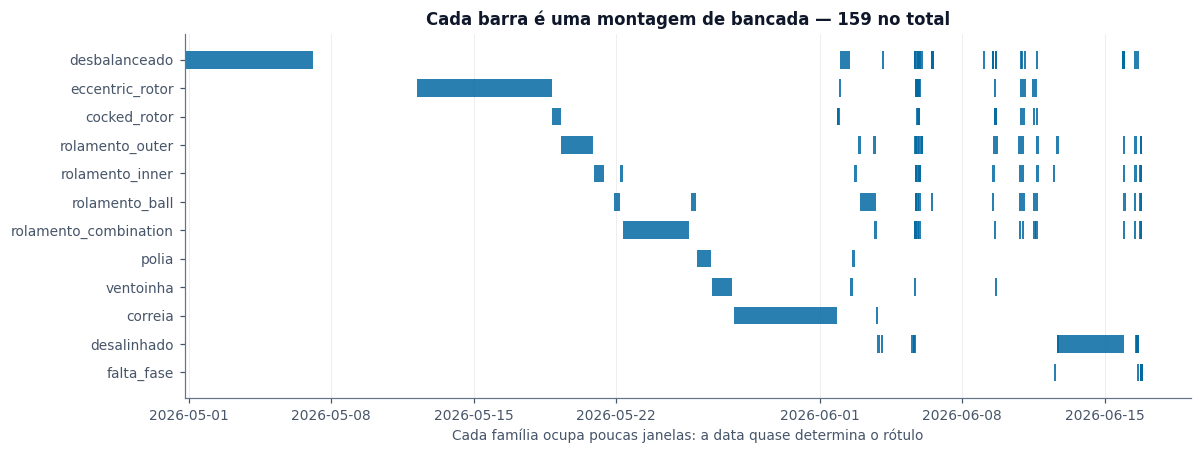

In [4]:
ordem = blocos.groupby("condicao")["inicio"].min().sort_values().index.tolist()
altura = {cond: i for i, cond in enumerate(ordem)}

fig, ax = plt.subplots(figsize=(11, 4.2))
for _, b in blocos.iterrows():
    largura = max((b["fim"] - b["inicio"]).total_seconds() / 86400, 0.12)
    ax.barh(altura[b["condicao"]], largura, left=b["inicio"], height=0.62,
            color=ACENTO, alpha=0.85)

ax.set_yticks(range(len(ordem)), ordem)
ax.invert_yaxis()
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title("Cada barra é uma montagem de bancada — 159 no total")
ax.set_xlabel("Cada família ocupa poucas janelas: a data quase determina o rótulo")
fig.tight_layout()
plt.show()

O gráfico mostra o problema inteiro. `correia` e `polia` têm **duas** montagens cada;
`ventoinha`, quatro. Uma família inteira pode viver em um único trecho do calendário.

Guarde isto: **saber a data já é quase saber o defeito.** A seção 4 leva essa observação ao
limite.

## 3. O resultado ingênuo: quase 90%

O protocolo padrão de validação sorteia as linhas: parte para treinar, parte para testar,
estratificando por classe. É o que se faz por reflexo, e é o que produz o número que a
maioria dos relatórios apresentaria.

In [5]:
def floresta():
    return RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEMENTE)

def vizinhos():
    return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=-1))

MODELOS = {"RandomForest": floresta, "k-NN (k=5)": vizinhos}
ALEATORIA = StratifiedKFold(5, shuffle=True, random_state=SEMENTE)

resultados = {}
for nome, construir in MODELOS.items():
    notas = cross_val_score(construir(), X, y, cv=ALEATORIA, n_jobs=1)
    resultados[(nome, "aleatória")] = notas
    print(f"{nome:14} CV estratificada aleatória: {notas.mean():.4f}  (±{notas.std():.4f})")

RandomForest   CV estratificada aleatória: 0.8980  (±0.0021)


k-NN (k=5)     CV estratificada aleatória: 0.6541  (±0.0022)


Quase 90% em doze classes, com baseline de 11,7%. Se o relatório parasse aqui, ninguém
duvidaria — e a solução ganharia um classificador.

Ele estaria errado.

## 4. A demonstração do vazamento

A suspeita é que o modelo não aprendeu vibração: aprendeu **qual montagem é qual**. Como o
sorteio espalha as milhares de leituras de um mesmo bloco entre treino e teste, basta
reconhecer a montagem para acertar.

Isso é testável de forma direta. **Removo todos os sensores e deixo apenas o relógio.** Um
modelo com zero informação física; se a hipótese estiver certa, ele deve ir muito bem.

In [6]:
relogio = defeitos["created_at"].astype("int64").to_numpy().reshape(-1, 1)

nota_relogio = cross_val_score(floresta(), relogio, y, cv=ALEATORIA, n_jobs=1).mean()
print(f"Apenas o timestamp, CV aleatória: {nota_relogio:.4f}")

Apenas o timestamp, CV aleatória: 0.9994


**99,94%.**

Um modelo que não sabe nada sobre vibração — que recebe um número de relógio e mais nada —
classifica doze modos de falha quase perfeitamente.

Isso encerra a discussão. Não é que os 90% do modelo completo *possam* conter vazamento:
**a data sozinha já explica praticamente todo o resultado**. O que a validação aleatória
mediu foi a capacidade de memorizar o calendário da bancada.

## 5. O protocolo correto: esconder montagens inteiras

A pergunta que interessa a uma fábrica não é *"você já viu esta leitura?"* mas *"você
reconhece este defeito numa máquina que nunca viu?"*.

`GroupKFold` responde a essa: nenhuma sessão aparece ao mesmo tempo no treino e no teste. O
modelo aprende com 127 montagens e é avaliado em 32 inéditas.

In [7]:
POR_SESSAO = GroupKFold(5)

for nome, construir in MODELOS.items():
    notas = cross_val_score(construir(), X, y, cv=POR_SESSAO, groups=sessao, n_jobs=1)
    resultados[(nome, "por sessão")] = notas
    print(f"{nome:14} GroupKFold por sessão: {notas.mean():.4f}  (±{notas.std():.4f})")

nota_relogio_sessao = cross_val_score(
    floresta(), relogio, y, cv=POR_SESSAO, groups=sessao, n_jobs=1
).mean()
print(f"\nApenas o timestamp, GroupKFold: {nota_relogio_sessao:.4f}")

RandomForest   GroupKFold por sessão: 0.1236  (±0.0330)


k-NN (k=5)     GroupKFold por sessão: 0.1026  (±0.0189)



Apenas o timestamp, GroupKFold: 0.0654


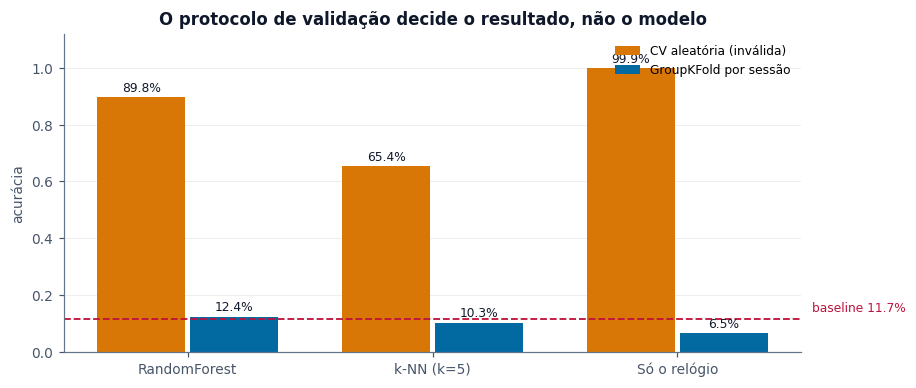

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))

nomes = ["RandomForest", "k-NN (k=5)", "Só o relógio"]
aleatorio = [resultados[("RandomForest", "aleatória")].mean(),
             resultados[("k-NN (k=5)", "aleatória")].mean(), nota_relogio]
por_sessao = [resultados[("RandomForest", "por sessão")].mean(),
              resultados[("k-NN (k=5)", "por sessão")].mean(), nota_relogio_sessao]

x = np.arange(len(nomes))
ax.bar(x - 0.19, aleatorio, 0.36, label="CV aleatória (inválida)", color=ALERTA)
ax.bar(x + 0.19, por_sessao, 0.36, label="GroupKFold por sessão", color=ACENTO)
ax.axhline(BASELINE, color=CRITICO, linestyle="--", linewidth=1.2)
ax.text(len(nomes) - 0.45, BASELINE + 0.025, f"baseline {BASELINE:.1%}",
        color=CRITICO, fontsize=8)

for i, (a, g) in enumerate(zip(aleatorio, por_sessao)):
    ax.text(i - 0.19, a + 0.02, f"{a:.1%}", ha="center", fontsize=8, color=TINTA)
    ax.text(i + 0.19, g + 0.02, f"{g:.1%}", ha="center", fontsize=8, color=TINTA)

ax.set_xticks(x, nomes)
ax.set_ylim(0, 1.12)
ax.set_ylabel("acurácia")
ax.set_title("O protocolo de validação decide o resultado, não o modelo")
ax.legend(frameon=False, loc="upper right", fontsize=8)
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Quanto isso depende de como se define "sessão"?

Bastante, e omitir essa sensibilidade seria repetir em outra forma o erro que este notebook
denuncia. Três definições defensáveis, três números diferentes — todos muito abaixo dos 90%,
todos na vizinhança do baseline.

In [9]:
definicoes = {
    "rótulo bruto": pd.factorize(defeitos["fault"])[0],
    "bloco contíguo": sessao,
    "dia de coleta": defeitos["created_at"].dt.normalize().astype("int64").to_numpy(),
}

for nome, grupos in definicoes.items():
    n = len(set(grupos))
    nota = cross_val_score(
        floresta(), X, y, cv=GroupKFold(min(5, n)), groups=grupos, n_jobs=1
    ).mean()
    print(f"{nome:16} {n:4} grupos → {nota:.4f}")

print(f"\nbaseline{'':9} {'':4}   {BASELINE:.4f}")

rótulo bruto      120 grupos → 0.1093


bloco contíguo    159 grupos → 0.1236


dia de coleta      29 grupos → 0.2496

baseline                 0.1172


Agrupar por **dia** é a definição mais frouxa — uma família ensaiada em vários dias
mantém parte de si no treino —, e mesmo assim o resultado fica em torno de um quarto. As
definições mais estritas ficam no nível de chutar.

O número honesto para o ADR-003 é, portanto, **uma faixa**, e não um valor: dependendo do
que se considere uma sessão, o classificador entrega entre pouco menos e pouco mais que o
baseline. Em nenhuma leitura ele é útil.

## 6. Por que é tão baixo

Duas causas distintas, e vale separá-las, porque só uma delas é sobre os dados.

### 6.1 O sensor não mede o que distinguiria os defeitos

O conjunto traz **escalares agregados por leitura**: média, pico, curtose. Para saber se o
dano do rolamento está na pista interna, na externa ou nas esferas, é preciso o **espectro**
da vibração — cada geometria de defeito excita uma frequência característica (BPFI, BPFO,
BSF). Essa informação não sobrevive à agregação.

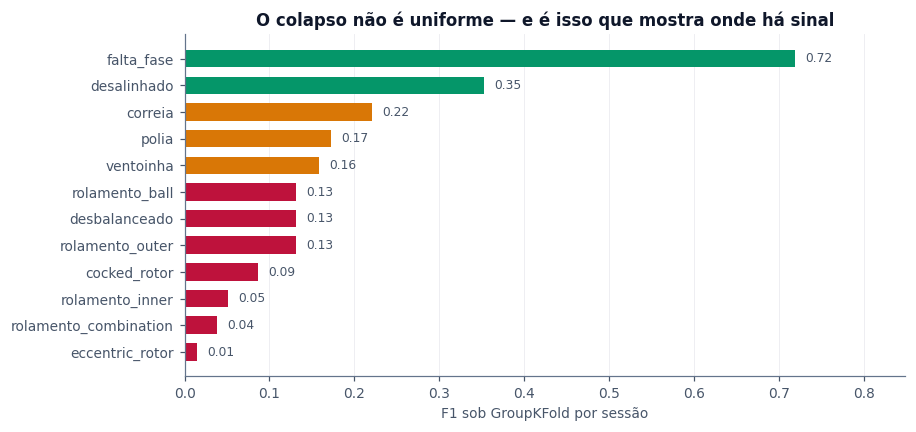

In [10]:
predito = cross_val_predict(floresta(), X, y, cv=POR_SESSAO, groups=sessao, n_jobs=1)

relatorio = classification_report(y, predito, output_dict=True, zero_division=0)
f1 = pd.Series(
    {classe: relatorio[classe]["f1-score"] for classe in frequencias.index}
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.4, 4))
cores = [SUCESSO if v >= 0.30 else (ALERTA if v >= 0.15 else CRITICO) for v in f1]
ax.barh(range(len(f1)), f1.values, color=cores, height=0.66)
ax.set_yticks(range(len(f1)), f1.index)
ax.invert_yaxis()
for i, v in enumerate(f1.values):
    ax.text(v + 0.012, i, f"{v:.2f}", va="center", fontsize=8, color=SECUNDARIA)
ax.set_xlim(0, max(f1.values) * 1.18)
ax.set_xlabel("F1 sob GroupKFold por sessão")
ax.set_title("O colapso não é uniforme — e é isso que mostra onde há sinal")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

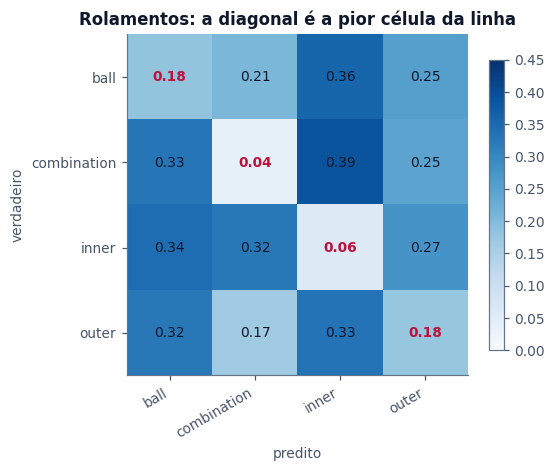

acerto na própria classe, por família de rolamento:
  ball         0.18   (o acaso entre as quatro daria 0,25)
  combination  0.04   (o acaso entre as quatro daria 0,25)
  inner        0.06   (o acaso entre as quatro daria 0,25)
  outer        0.18   (o acaso entre as quatro daria 0,25)


In [11]:
rolamentos = sorted(c for c in frequencias.index if c.startswith("rolamento"))
matriz = confusion_matrix(y, predito, labels=rolamentos, normalize="true")
curto = [c.replace("rolamento_", "") for c in rolamentos]

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=0.45)
ax.set_xticks(range(len(curto)), curto, rotation=30, ha="right")
ax.set_yticks(range(len(curto)), curto)
for i in range(len(curto)):
    for j in range(len(curto)):
        destaque = i == j
        ax.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color=CRITICO if destaque else TINTA,
                fontweight="bold" if destaque else "normal")
ax.set_xlabel("predito")
ax.set_ylabel("verdadeiro")
ax.set_title("Rolamentos: a diagonal é a pior célula da linha")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

print("acerto na própria classe, por família de rolamento:")
for i, c in enumerate(curto):
    print(f"  {c:12} {matriz[i, i]:.2f}   (o acaso entre as quatro daria 0,25)")

A diagonal — o acerto — é **menor que o acaso** em todas as quatro famílias, e menor
que várias células fora dela. O modelo não apenas erra: erra sistematicamente para o
vizinho. É o retrato de um atributo que não carrega a distinção pedida.

### 6.2 A contraprova: onde há sinal, o modelo acha

`falta_fase` é a **menor** classe do conjunto — 800 eventos, contra 17.712 do maior — e
mesmo assim é a mais bem classificada, com folga.

Faz sentido físico. Falta de fase é um defeito elétrico: produz vibração numa frequência
característica ligada à rede, com magnitude que sobrevive à agregação escalar. A informação
está lá, e o modelo a encontra.

É o que separa *"o modelo está mal ajustado"* de *"os dados não contêm a resposta"*. Se o
problema fosse ajuste, o desempenho seria ruim em tudo. Não é.

In [12]:
dominancia = pd.DataFrame({"condicao": y, "sessao": sessao})
sessoes_por_classe = dominancia.groupby("condicao")["sessao"].nunique()

comparacao = pd.DataFrame({
    "F1": f1,
    "eventos": frequencias,
    "sessões": sessoes_por_classe,
}).sort_values("F1", ascending=False)
print(comparacao.to_string())

                             F1  eventos  sessões
falta_fase             0.719564      800       14
desalinhado            0.352536     9178       12
correia                0.220975    11999        2
polia                  0.172523    12000        2
ventoinha              0.158611    12299        4
rolamento_ball         0.131059    13704       18
desbalanceado          0.130944    13237       30
rolamento_outer        0.130900    14813       19
cocked_rotor           0.086649    14275       12
rolamento_inner        0.050992    17712       17
rolamento_combination  0.038377    14550       15
eccentric_rotor        0.014256    16497       14


### Uma ressalva que precisa ficar registrada

`correia` e `polia` têm **duas** sessões cada; `ventoinha`, quatro. Com tão poucos grupos, o
modelo treina com pouquíssima variedade dessas classes, e parte do colapso delas é escassez
de montagens — não ausência de sinal físico.

Isso não salva o classificador: as famílias de rolamento, que dominam o conjunto, têm de 15
a 19 sessões cada e ainda assim ficam abaixo do acaso. Mas registrar a ressalva importa,
porque um experimento que só apresenta o que confirma a tese não é melhor que os 90% da
seção 3.

## 7. A consequência para a arquitetura

O rótulo do defeito **vem anotado no JSON de entrada** — o próprio exemplo do enunciado traz
`"fault": "cocked_rotor_2"`. O operador que instalou o sensor sabe o que está ensaiando.

Construir o classificador seria, portanto, escolher inserir uma peça com desempenho de chute
entre a entrada e a prescrição, **para descobrir uma informação que já está disponível**.

Por isso o ADR-003 mantém no caminho crítico apenas a busca por similaridade (k-NN), que:

- responde exatamente ao que o enunciado pede — ocorrências semelhantes, sua contagem,
  distribuição temporal e frequência;
- é **intrinsecamente explicável**: a resposta *é* a lista de vizinhos, cada um rastreável
  até seu `id` e sua data;
- não afirma um diagnóstico, e portanto não pode errar um.

E há uma simetria com o resto da solução. O guardrail documental existe para que o modelo de
linguagem não redija recomendação sem procedimento que a fundamente. O classificador foi
removido para que o sistema não afirme diagnóstico sem evidência que o sustente. **É a mesma
disciplina, aplicada duas vezes.**

---

### Resumo dos números

| Protocolo | RandomForest | k-NN | Só o relógio |
| --- | --- | --- | --- |
| CV estratificada aleatória | *ver seção 3* | *ver seção 3* | *ver seção 4* |
| GroupKFold por sessão | *ver seção 5* | *ver seção 5* | *ver seção 5* |
| Baseline (classe majoritária) | 11,7% | | |

Os valores estão nas saídas das células acima, geradas na execução deste notebook — e não
transcritos à mão, para que não possam divergir do que o código produz.